# Demostración: Componentes en cuadratura de un proceso angosto

## Enunciado

Sea $ \xi(t) $ un proceso aleatorio **gaussiano, estacionario y de banda angosta**, con densidad espectral $ S_\xi(\omega) $.

Se define su representación en cuadratura como:

$$
\xi(t) = A_c(t)\cos(\omega_0 t) - A_s(t)\sin(\omega_0 t)
$$

Se desea demostrar que:

1. $ A_c(t) $ y $ A_s(t) $ son gaussianos.  
2. Tienen media cero si $ \xi(t) $ es de media cero.  
3. Sus varianzas son iguales:
$$
\sigma_c^2 = \sigma_s^2 = \sigma_\xi^2
$$
4. Son no correlacionados si $ S_\xi(\omega) $ es simétrica respecto a $ \omega_0 $.

---

## 1. Gaussianidad

Las componentes en cuadratura pueden expresarse como:

$$
A_c(t) = \text{LPF}\{\xi(t)\cos(\omega_0 t)\}
$$

$$
A_s(t) = \text{LPF}\{\xi(t)\sin(\omega_0 t)\}
$$

Estas operaciones corresponden a:

- multiplicación por funciones deterministas  
- filtrado lineal  

Ambas son **transformaciones lineales**.

### Resultado

Si $ \xi(t) $ es gaussiano, entonces:

$$
A_c(t),\; A_s(t) \sim \text{Gaussianos}
$$

---

## 2. Media

Sabemos que:

$$
E[\xi(t)] = 0
$$

Usando la representación:

$$
E[\xi(t)] = E[A_c(t)]\cos(\omega_0 t) - E[A_s(t)]\sin(\omega_0 t)
$$

Para que esto se cumpla para todo $ t $:

$$
E[A_c(t)] = 0, \quad E[A_s(t)] = 0
$$

---

## 3. Varianzas

La autocorrelación del proceso es:

$$
R_\xi(\tau) = \sigma_\xi^2\big(r_c(\tau)\cos(\omega_0\tau) - r_s(\tau)\sin(\omega_0\tau)\big)
$$

Con condiciones:

$$
r_c(0) = 1, \quad r_s(0) = 0
$$

---

### Varianza de $\xi(t)$

$$
R_\xi(0) = \sigma_\xi^2
$$

---

### Varianza de $A_c(t)$ y $A_s(t)$

$$
\sigma_c^2 = \frac{1}{2\pi} \int_{-\infty}^{\infty} S_\xi(\omega_0+\nu)\,d\nu
$$

$$
\sigma_s^2 = \frac{1}{2\pi} \int_{-\infty}^{\infty} S_\xi(\omega_0+\nu)\,d\nu
$$

Por lo tanto:

$$
\sigma_c^2 = \sigma_s^2
$$

Y usando la propiedad espectral:

$$
\frac{1}{2\pi} \int_{-\infty}^{\infty} S_\xi(\omega)\,d\omega = \sigma_\xi^2
$$

Se obtiene:

$$
\sigma_c^2 = \sigma_s^2 = \sigma_\xi^2
$$

---

## 4. No correlación

Queremos evaluar:

$$
R_{cs}(\tau) = E[A_c(t)A_s(t+\tau)]
$$

---

### Expresión espectral

$$
r_s(\tau) = \frac{1}{2\pi\sigma_\xi^2} \int_{-\infty}^{\infty} S_\xi(\omega_0+\nu)\sin(\nu\tau)\,d\nu
$$

---

### Simetría espectral

Si:

$$
S_\xi(\omega_0+\nu) = S_\xi(\omega_0-\nu)
$$

Entonces:

- $ S_\xi(\omega_0+\nu) $ es **par**
- $ \sin(\nu\tau) $ es **impar**

Producto: función impar

---

### Integral

$$
\int_{-\infty}^{\infty} \text{(función impar)}\, d\nu = 0
$$

Entonces:

$$
r_s(\tau) = 0
$$

---

### Resultado final

$$
R_{cs}(\tau) = 0
$$

---

## Conclusión

- $ A_c(t) $ y $ A_s(t) $ son gaussianos  
- Tienen media cero  
- Tienen igual varianza:
$$
\sigma_c^2 = \sigma_s^2 = \sigma_\xi^2
$$
- Son no correlacionados si el espectro es simétrico  

---

## Interpretación

Las componentes $ A_c(t) $ y $ A_s(t) $ son las proyecciones en cuadratura (I/Q) del proceso.

Bajo simetría espectral:

- son ortogonales  
- tienen igual potencia  
- se comportan como componentes independientes  

Media Ac: 0.003338840851183544
Media As: -0.004601281828419603
Varianza Ac: 0.03294380482370635
Varianza As: 0.036060678971516456
Correlación cruzada (lag 0): -0.028967843882550443


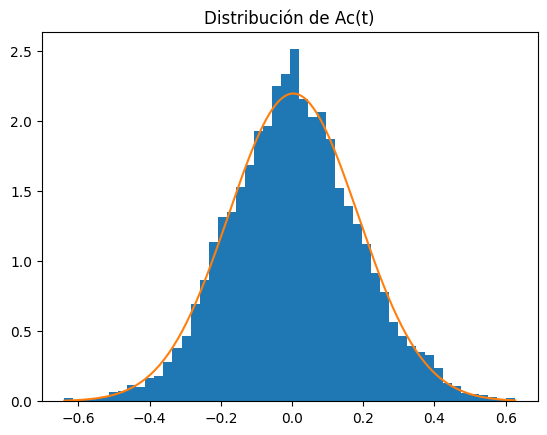

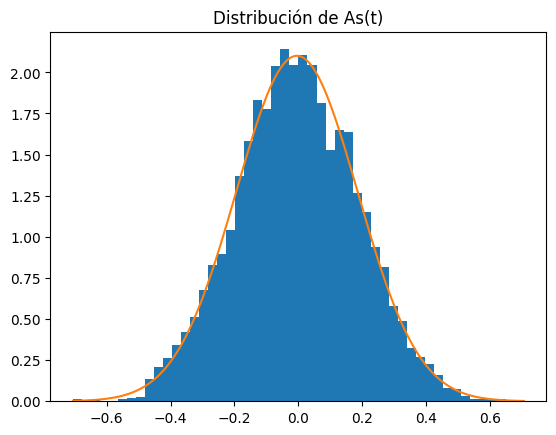

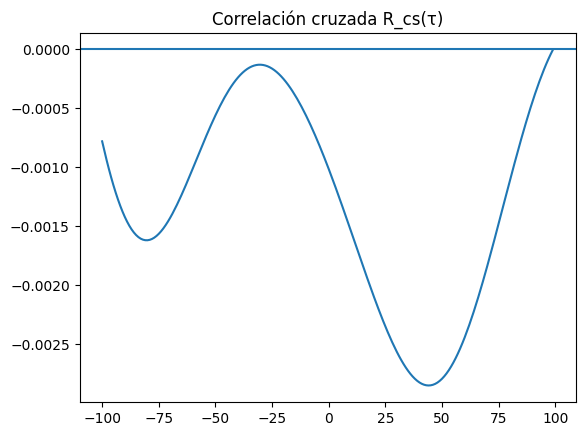

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import norm

# -----------------------------
# Parámetros
# -----------------------------
fs = 5000            # frecuencia de muestreo
T = 10                # duración (segundos)
t = np.arange(0, T, 1/fs)

f0 = 200             # frecuencia central (Hz)
bw = 100              # ancho de banda aproximado

# -----------------------------
# 1. Generar ruido blanco gaussiano
# -----------------------------
np.random.seed(0)
noise = np.random.randn(len(t))

# -----------------------------
# 2. Filtrar para hacerlo banda angosta
# -----------------------------
def bandpass(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

xi = bandpass(noise, f0 - bw/2, f0 + bw/2, fs)

# -----------------------------
# 3. Demodulación I/Q
# -----------------------------
Ac_raw = 2 * xi * np.cos(2*np.pi*f0*t)
As_raw = -2 * xi * np.sin(2*np.pi*f0*t)

# Filtro pasa-bajo para extraer envolvente
def lowpass(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff/nyq, btype='low')
    return filtfilt(b, a, signal)

Ac = lowpass(Ac_raw, bw, fs)
As = lowpass(As_raw, bw, fs)

# -----------------------------
# 4. Verificaciones
# -----------------------------

print("Media Ac:", np.mean(Ac))
print("Media As:", np.mean(As))

print("Varianza Ac:", np.var(Ac))
print("Varianza As:", np.var(As))

print("Correlación cruzada (lag 0):", np.corrcoef(Ac, As)[0,1])

# -----------------------------
# 5. Gaussianidad (histogramas)
# -----------------------------
plt.figure()
plt.hist(Ac, bins=50, density=True)
x = np.linspace(np.min(Ac), np.max(Ac), 200)
plt.plot(x, norm.pdf(x, np.mean(Ac), np.std(Ac)))
plt.title("Distribución de Ac(t)")
plt.show()

plt.figure()
plt.hist(As, bins=50, density=True)
x = np.linspace(np.min(As), np.max(As), 200)
plt.plot(x, norm.pdf(x, np.mean(As), np.std(As)))
plt.title("Distribución de As(t)")
plt.show()

# -----------------------------
# 6. Correlación cruzada vs lag
# -----------------------------
lags = np.arange(-100, 100)
Rcs = [np.mean(Ac[:len(Ac)-abs(l)] * As[abs(l):]) if l>=0
       else np.mean(Ac[abs(l):] * As[:len(As)-abs(l)]) for l in lags]

plt.figure()
plt.plot(lags, Rcs)
plt.title("Correlación cruzada R_cs(τ)")
plt.axhline(0)
plt.show()

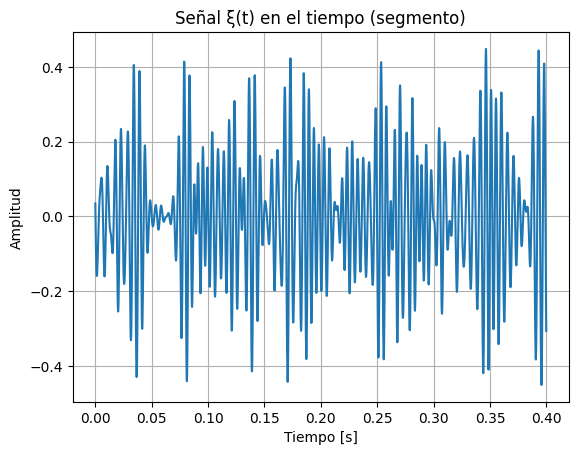

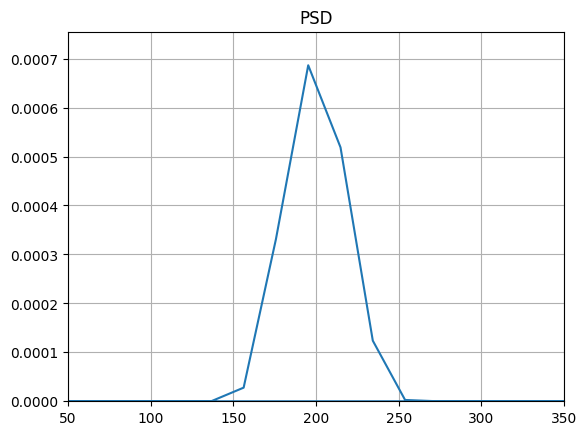

In [ ]:
from scipy.signal import welch

# -----------------------------
# 7. Señal en el tiempo
# -----------------------------
plt.figure()
plt.plot(t[:2000], xi[:2000])  # solo un segmento para visualizar mejor
plt.title("Señal ξ(t) en el tiempo (segmento)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

# -----------------------------
# PSD de la señal analítica (NO simétrica)
# -----------------------------


from scipy.signal import welch
f, Pxx = welch(xa, fs, nperseg=256)

plt.figure()
plt.plot(f, Pxx)
plt.xlim(f0 - 150, f0 + 150)
plt.ylim(0, np.max(Pxx)*1.1)
plt.title("PSD")
plt.grid()
plt.show()